# Flower Image Classification with CNNs and Transfer Learning

**Dataset:** Kaggle `junkal/flowerdatasets`  
**Goal:** Complete an end-to-end multi-class flower image classification project using Keras.

This notebook covers:

1. Dataset loading, understanding, cleaning, visualization, and stratified splitting
2. Baseline CNN from scratch: **3 convolutional layers + 3 fully connected layers**
3. Deeper CNN: **6 convolutional layers**, batch normalization, dropout, and global average pooling
4. Experiments: baseline vs deeper model, **SGD vs Adam**, and dropout ablation
5. Transfer learning with **MobileNetV2**
6. Evaluation using accuracy, precision, recall, F1-score, confusion matrix, and sample predictions

Run this in **Google Colab with GPU enabled**.

## 1. Setup

In [21]:
!pip -q install kagglehub scikit-learn

import os, time, random, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_SLUG = "junkal/flowerdatasets"
EXPECTED_CLASSES = ["daisy", "dandelion", "lily", "orchid", "rose", "sunflower", "tulip"]

BATCH_SIZE = 32
IMG_SIZE_SCRATCH = (128, 128)
IMG_SIZE_TRANSFER = (224, 224)

EPOCHS_BASELINE = 20
EPOCHS_DEEPER = 20
EPOCHS_OPTIMIZER = 12
EPOCHS_ABLATION = 12
EPOCHS_TL_FEATURE = 10
EPOCHS_TL_FINE = 8

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.19.0
GPU: []


## 2. Download / Load Dataset

The automatic method uses KaggleHub. If it fails, download the ZIP from Kaggle manually, upload it to Colab, and run the fallback section.

In [22]:
dataset_path = None
try:
    import kagglehub
    dataset_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    print("Dataset downloaded to:", dataset_path)
except Exception as e:
    print("Automatic KaggleHub download failed:", repr(e))
    print("Use the manual fallback below if needed.")


Dataset downloaded to: /kaggle/input/datasets/junkal/flowerdatasets


## 3. Data Understanding, Cleaning, and Visualization

The dataset represents images of seven flower species. Labels are inferred from the image parent folder names.

Images found before filtering: 11531
Detected labels: ['daisy', 'dandelion', 'lily', 'orchid', 'rose', 'sunflower', 'tulip']
Corrupted images removed: 0
Total usable images: 11531
label
daisy        1759
dandelion    1495
lily         1618
orchid       1851
rose         1489
sunflower    1713
tulip        1606
Name: count, dtype: int64


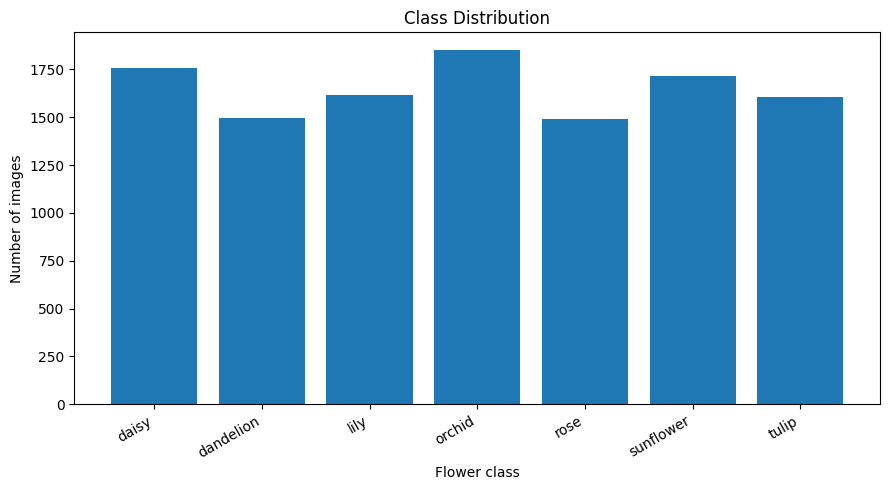

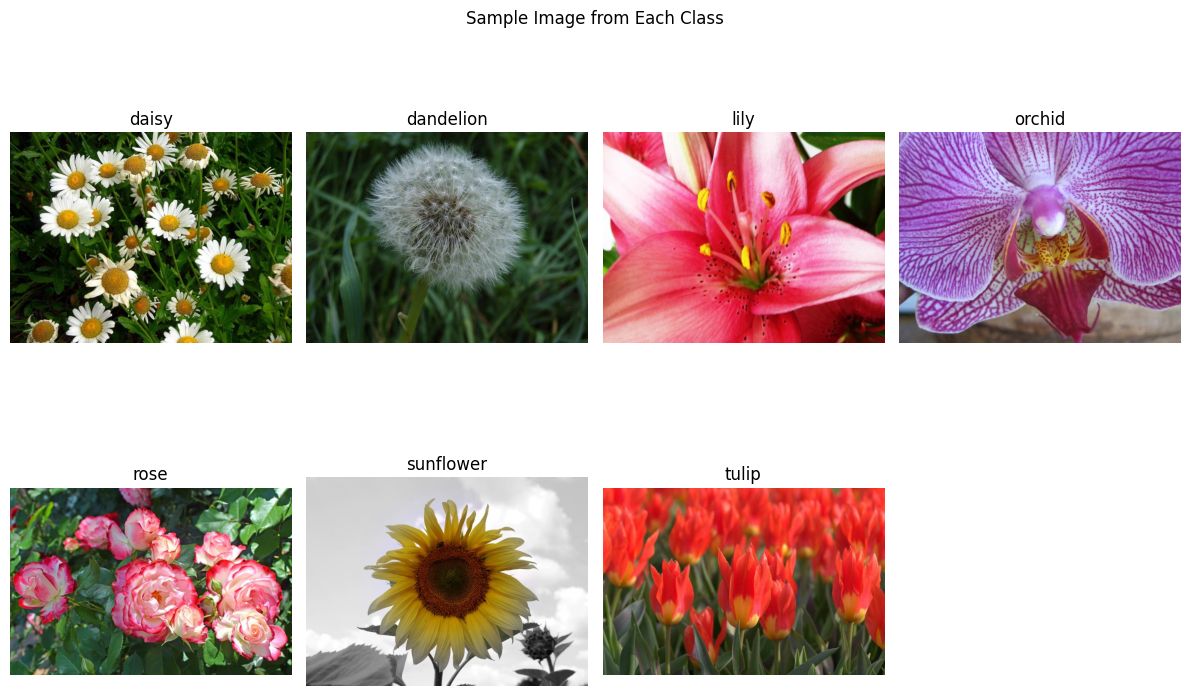

             width      height
count   500.000000  500.000000
mean    661.620000  526.564000
std     109.078503   82.779773
min     236.000000  196.000000
25%     594.500000  500.000000
50%     666.000000  500.000000
75%     750.000000  500.000000
max    1022.000000  888.000000


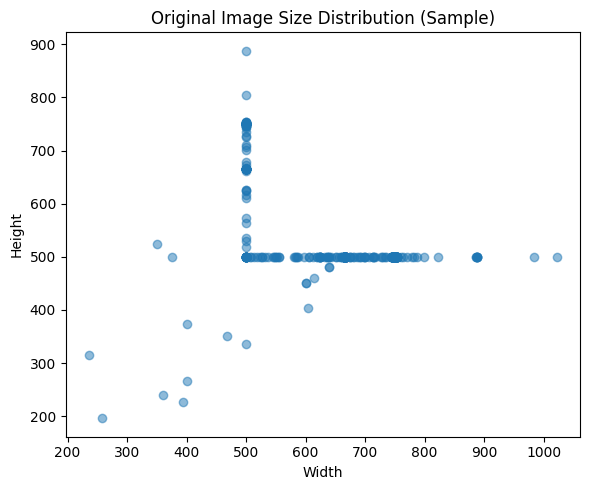

In [23]:
if dataset_path is None:
    raise ValueError("dataset_path is not set. Use KaggleHub or the manual upload fallback.")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
records = []
for p in Path(dataset_path).rglob("*"):
    if p.suffix.lower() in IMAGE_EXTENSIONS:
        records.append({"path": str(p), "label": p.parent.name.lower().strip()})

df = pd.DataFrame(records).drop_duplicates()
print("Images found before filtering:", len(df))
print("Detected labels:", sorted(df["label"].unique()))

# Keep only the known flower classes from this Kaggle dataset.
df = df[df["label"].isin(EXPECTED_CLASSES)].reset_index(drop=True)
if df.empty:
    raise ValueError("No expected flower class folders found. Inspect the extracted dataset structure.")

# Remove unreadable/corrupted images.
valid = []
for file_path in df["path"]:
    try:
        with Image.open(file_path) as img:
            img.verify()
        valid.append(True)
    except (UnidentifiedImageError, OSError, ValueError):
        valid.append(False)

print("Corrupted images removed:", len(valid) - sum(valid))
df = df[valid].reset_index(drop=True)

class_counts = df["label"].value_counts().sort_index()
print("Total usable images:", len(df))
print(class_counts)

plt.figure(figsize=(9, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Flower class")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
for i, cls in enumerate(sorted(df["label"].unique())):
    sample_path = df[df["label"] == cls].sample(1, random_state=SEED)["path"].iloc[0]
    img = Image.open(sample_path).convert("RGB")
    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample Image from Each Class")
plt.tight_layout()
plt.show()

# Inspect original dimensions using a sample.
size_records = []
for file_path in df.sample(min(500, len(df)), random_state=SEED)["path"]:
    with Image.open(file_path) as img:
        size_records.append(img.size)
sizes_df = pd.DataFrame(size_records, columns=["width", "height"])
print(sizes_df.describe())

plt.figure(figsize=(6, 5))
plt.scatter(sizes_df["width"], sizes_df["height"], alpha=0.5)
plt.title("Original Image Size Distribution (Sample)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

## 4. Stratified Train/Validation/Test Split

A **70/15/15 stratified split** is used. Training fits the model, validation supports tuning and early stopping, and test evaluation provides the final unbiased result.

Classes: ['daisy', 'dandelion', 'lily', 'orchid', 'rose', 'sunflower', 'tulip']
Train: 8071 Validation: 1730 Test: 1730


,train,validation,test
label,,,
daisy,1231,264,264
dandelion,1046,224,225
lily,1133,243,242
orchid,1296,277,278
rose,1042,224,223
sunflower,1199,257,257
tulip,1124,241,241


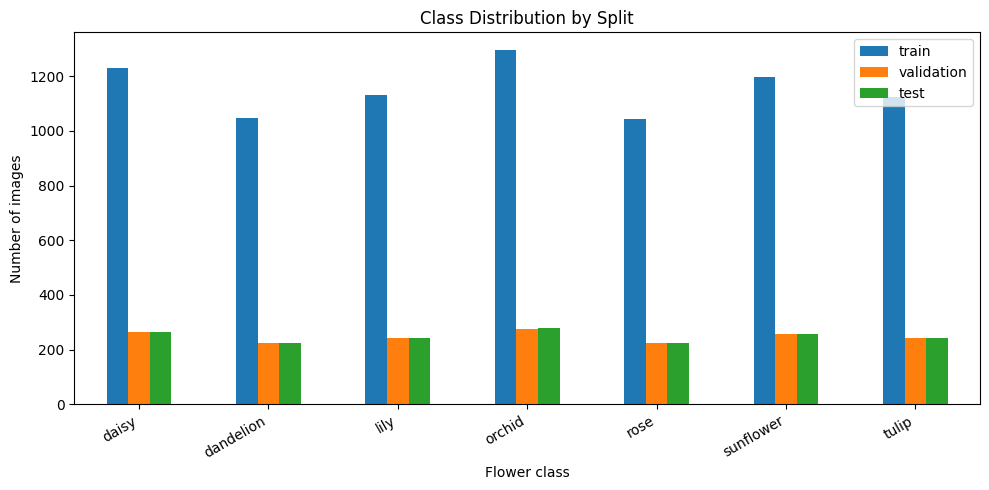

In [24]:
class_names = sorted(df["label"].unique())
class_to_id = {name: idx for idx, name in enumerate(class_names)}
df["label_id"] = df["label"].map(class_to_id).astype("int32")
num_classes = len(class_names)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label_id"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=SEED
)

print("Classes:", class_names)
print("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))

split_counts = pd.DataFrame({
    "train": train_df["label"].value_counts().sort_index(),
    "validation": val_df["label"].value_counts().sort_index(),
    "test": test_df["label"].value_counts().sort_index(),
}).fillna(0).astype(int)
display(split_counts)

split_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Class Distribution by Split")
plt.xlabel("Flower class")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Preprocessing, Data Pipelines, and Augmentation

From-scratch CNN models use **128 × 128** images normalized to **[0, 1]**. Transfer learning uses **224 × 224** raw images and MobileNetV2 preprocessing inside the model.

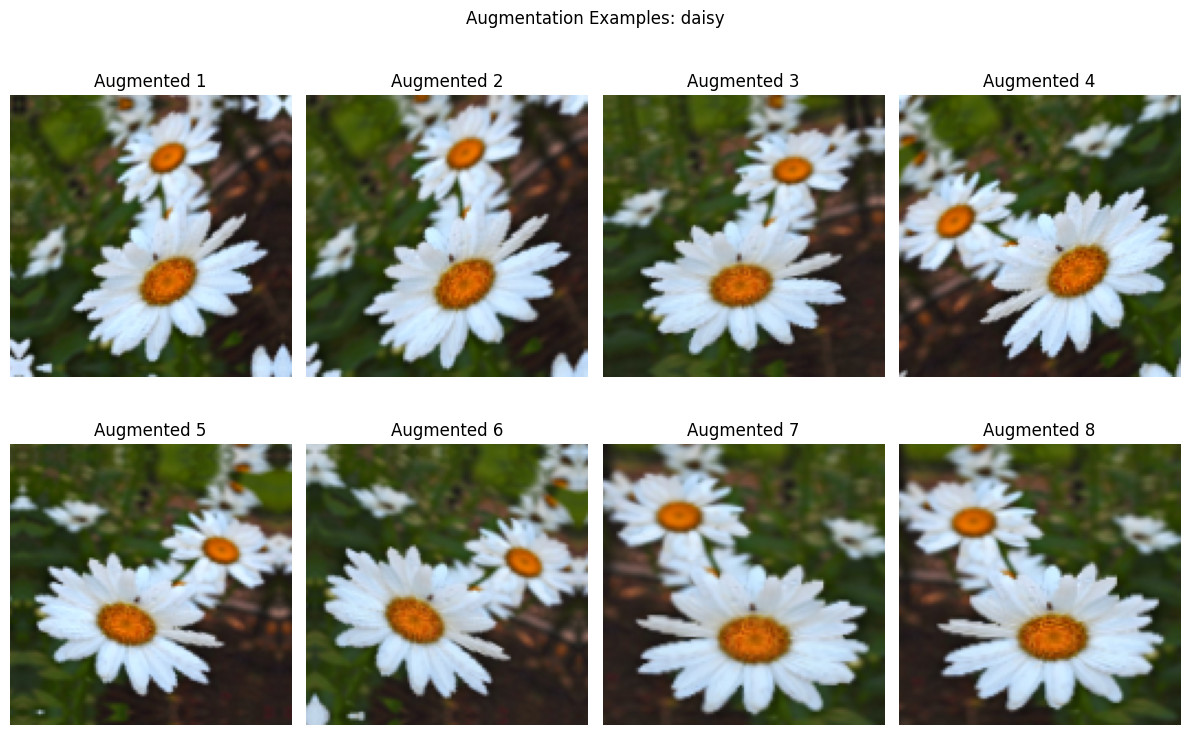

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label, img_size=(128, 128), mode="rescale"):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
    if mode == "rescale":
        image = image / 255.0
    return image, label

def make_dataset(dataframe, img_size, mode="rescale", shuffle=False):
    paths = dataframe["path"].values.astype(str)
    labels = dataframe["label_id"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y, img_size, mode), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def make_augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ], name="data_augmentation")

train_ds = make_dataset(train_df, IMG_SIZE_SCRATCH, mode="rescale", shuffle=True)
val_ds = make_dataset(val_df, IMG_SIZE_SCRATCH, mode="rescale")
test_ds = make_dataset(test_df, IMG_SIZE_SCRATCH, mode="rescale")

# Visualize sample augmentations.
viz_aug = make_augmentation()
for batch_images, batch_labels in train_ds.take(1):
    sample_image = batch_images[0]
    sample_label = class_names[int(batch_labels[0])]
    break

plt.figure(figsize=(12, 8))
for i in range(8):
    augmented = viz_aug(tf.expand_dims(sample_image, 0), training=True)[0]
    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(tf.clip_by_value(augmented, 0, 1))
    ax.set_title(f"Augmented {i+1}")
    ax.axis("off")
plt.suptitle(f"Augmentation Examples: {sample_label}")
plt.tight_layout()
plt.show()

## 6. Training and Evaluation Helpers

In [26]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="training loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="validation loss")
    plt.title(f"{title}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist["accuracy"], label="training accuracy")
    if "val_accuracy" in hist:
        plt.plot(hist["val_accuracy"], label="validation accuracy")
    plt.title(f"{title}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


def train_model(model, train_data, val_data, epochs, model_name):
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
    ]

    start = time.perf_counter()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.perf_counter() - start

    print(f"{model_name} training time: {elapsed:.2f} seconds")

    model.save(OUTPUT_DIR / f"{model_name}.keras")

    return history, elapsed


def collect_predictions(model, dataset):
    y_true, y_pred = [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.tolist())

    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, dataset, model_name):
    y_true, y_pred = collect_predictions(model, dataset)

    print(f"\nClassification Report: {model_name}")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

    return metrics


def show_predictions(model, dataset, title, n=9):
    images, labels = next(iter(dataset.unbatch().batch(n)))

    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(10, 10))

    for i in range(min(n, len(images))):
        img = images[i].numpy()

        if img.max() > 1:
            img = img / 255.0

        ax = plt.subplot(3, 3, i + 1)
        ax.imshow(np.clip(img, 0, 1))

        ax.set_title(
            f"True: {class_names[int(labels[i])]}\n"
            f"Pred: {class_names[int(preds[i])]} ({probs[i][preds[i]]:.2f})"
        )

        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


results = []

## 7. Part A — Baseline CNN from Scratch

The baseline has **3 convolutional layers**, each followed by max pooling, then **3 fully connected layers**, and a softmax output layer.

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,719 (32.52 MB)

 Trainable params: 8,523,719 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 199s 775ms/step - accuracy: 0.5270 - loss: 1.2602 - val_accuracy: 0.7913 - val_loss: 0.6142 - learning_rate: 0.0010
Epoch 2/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 205s 810ms/step - accuracy: 0.7914 - loss: 0.6062 - val_accuracy: 0.7468 - val_loss: 0.7670 - learning_rate: 0.0010
Epoch 3/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 197s 779ms/step - accuracy: 0.8249 - loss: 0.5072 - val_accuracy: 0.8301 - val_loss: 0.5231 - learning_rate: 0.0010
Epoch 4/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 206s 813ms/step - accuracy: 0.8571 - loss: 0.4093 - val_accuracy: 0.8601 - val_loss: 0.4352 - learning_rate: 0.0010
Epoch 5/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 197s 777ms/step - accuracy: 0.8795 - loss: 0.3511 - val_accuracy: 0.8815 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 6/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 196s 773ms/step - accuracy: 0.8846 - loss: 0.3289 - val_accuracy: 0.8676 - val_loss: 0.4242 - learning_rate: 0.0010
Epoch 7/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy

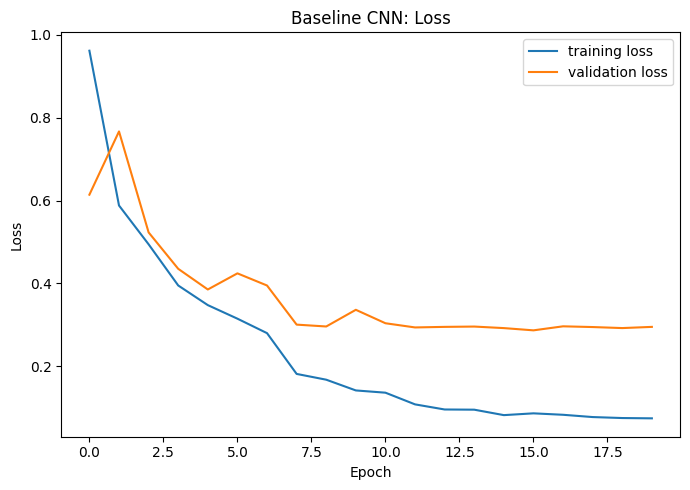

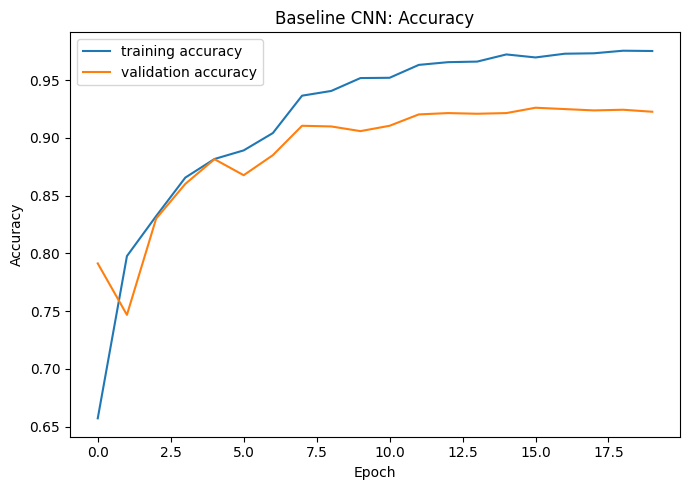


Classification Report: Baseline CNN
              precision    recall  f1-score   support

       daisy       0.96      0.92      0.94       264
   dandelion       0.95      0.98      0.97       225
        lily       0.92      0.96      0.94       242
      orchid       0.93      0.94      0.93       278
        rose       0.88      0.88      0.88       223
   sunflower       0.97      0.97      0.97       257
       tulip       0.94      0.92      0.93       241

    accuracy                           0.94      1730
   macro avg       0.94      0.94      0.94      1730
weighted avg       0.94      0.94      0.94      1730



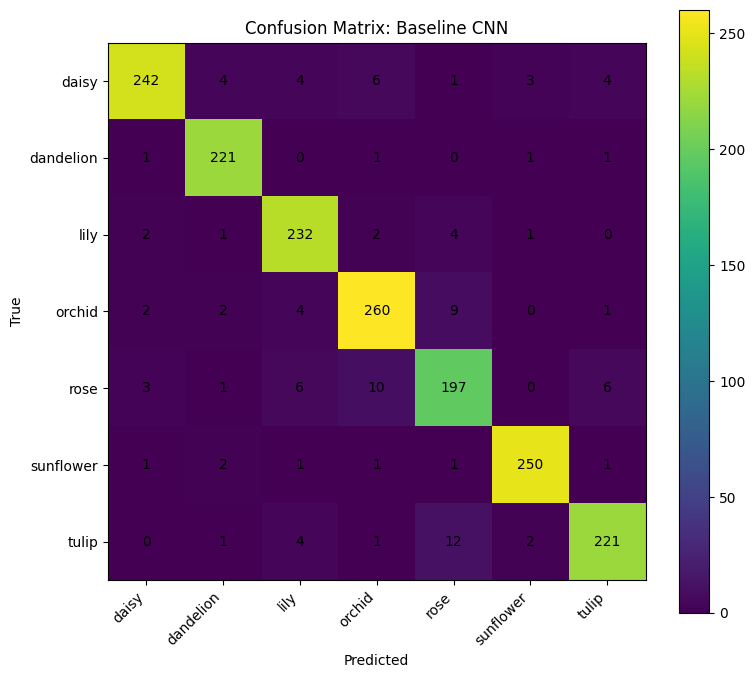

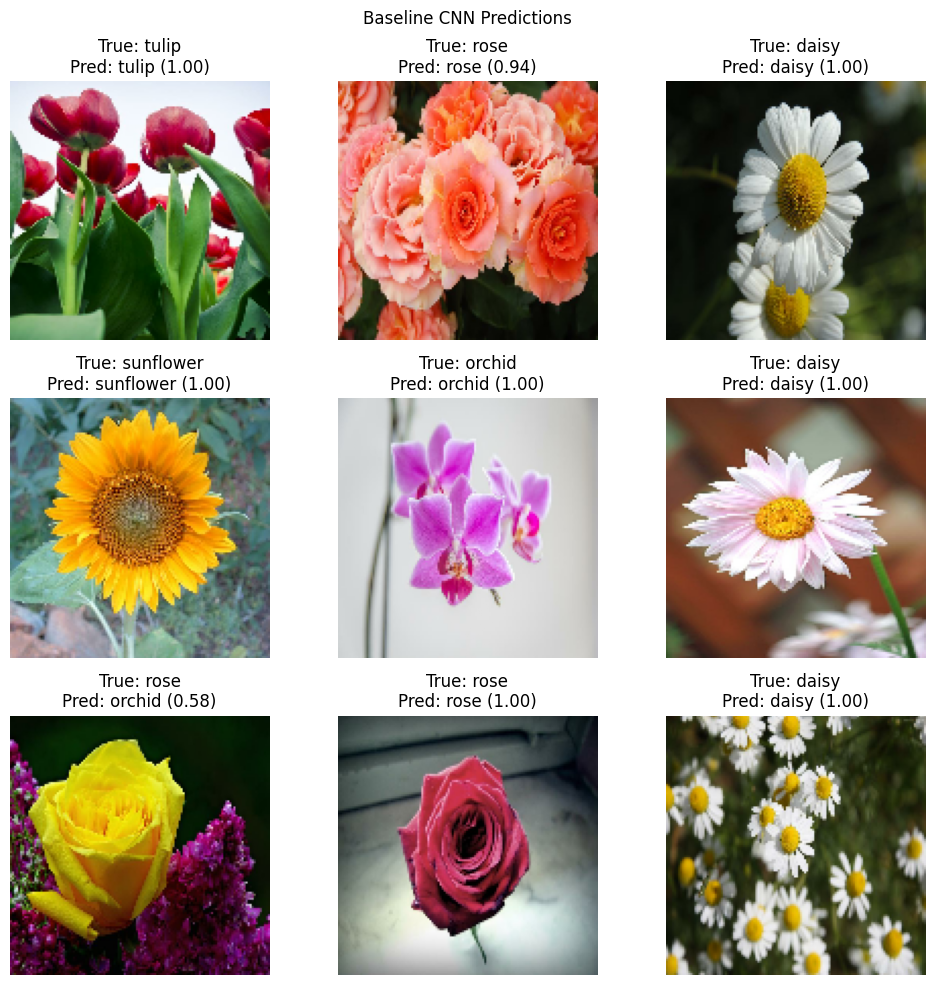

In [27]:
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=7):
    inputs = keras.Input(shape=input_shape)
    x = make_augmentation()(inputs)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn(IMG_SIZE_SCRATCH + (3,), num_classes)
baseline_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
baseline_model.summary()

baseline_history, baseline_time = train_model(baseline_model, train_ds, val_ds, EPOCHS_BASELINE, "baseline_cnn")
plot_history(baseline_history, "Baseline CNN")

m = evaluate_model(baseline_model, test_ds, "Baseline CNN")
m["training_time_seconds"] = baseline_time
results.append(m)
show_predictions(baseline_model, test_ds, "Baseline CNN Predictions")

## 8. Part A — Deeper CNN with Regularization

The deeper model has **6 convolutional layers**, which is double the baseline convolutional depth. Batch normalization and dropout are used as regularization techniques.

In [ ]:
def conv_block(x, filters, use_batchnorm=True):
    x = layers.Conv2D(filters, (3, 3), activation="relu", padding="same")(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3, 3), activation="relu", padding="same")(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    return layers.MaxPooling2D((2, 2))(x)

def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=7, use_batchnorm=True, use_dropout=True):
    inputs = keras.Input(shape=input_shape)
    x = make_augmentation()(inputs)
    x = conv_block(x, 32, use_batchnorm)
    if use_dropout: x = layers.Dropout(0.20)(x)
    x = conv_block(x, 64, use_batchnorm)
    if use_dropout: x = layers.Dropout(0.30)(x)
    x = conv_block(x, 128, use_batchnorm)
    if use_dropout: x = layers.Dropout(0.40)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    if use_batchnorm: x = layers.BatchNormalization()(x)
    if use_dropout: x = layers.Dropout(0.50)(x)
    x = layers.Dense(128, activation="relu")(x)
    if use_dropout: x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="deeper_regularized_cnn")

deeper_model = build_deeper_cnn(IMG_SIZE_SCRATCH + (3,), num_classes, True, True)
deeper_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
deeper_model.summary()

deeper_history, deeper_time = train_model(deeper_model, train_ds, val_ds, EPOCHS_DEEPER, "deeper_cnn_adam")
plot_history(deeper_history, "Deeper CNN + Adam")

m = evaluate_model(deeper_model, test_ds, "Deeper CNN + Adam")
m["training_time_seconds"] = deeper_time
results.append(m)
show_predictions(deeper_model, test_ds, "Deeper CNN + Adam Predictions")

Model: "deeper_regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 356,647 (1.36 MB)

 Trainable params: 355,239 (1.36 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 692s 3s/step - accuracy: 0.4574 - loss: 1.6028 - val_accuracy: 0.2116 - val_loss: 3.2568 - learning_rate: 0.0010
Epoch 2/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 681s 3s/step - accuracy: 0.6277 - loss: 1.0617 - val_accuracy: 0.5532 - val_loss: 1.2256 - learning_rate: 0.0010
Epoch 3/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 693s 3s/step - accuracy: 0.6952 - loss: 0.8570 - val_accuracy: 0.7543 - val_loss: 0.6959 - learning_rate: 0.0010
Epoch 4/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 690s 3s/step - accuracy: 0.7537 - loss: 0.7188 - val_accuracy: 0.6746 - val_loss: 1.3854 - learning_rate: 0.0010
Epoch 5/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 687s 3s/step - accuracy: 0.7791 - loss: 0.6554 - val_accuracy: 0.7682 - val_loss: 0.6823 - learning_rate: 0.0010
Epoch 6/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 688s 3s/step - accuracy: 0.8229 - loss: 0.5414 - val_accuracy: 0.8497 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 7/20
253/253 ━━━━━━━━━━━━━━━━━━━━ 690s 3s/step - accuracy: 0.8503 - loss: 0.

## 9. Experimentation — SGD vs Adam and Ablation Study

This section trains the deeper architecture with SGD and then trains an ablation version without dropout.

In [ ]:
# Optimizer comparison: SGD with momentum
deeper_sgd = build_deeper_cnn(IMG_SIZE_SCRATCH + (3,), num_classes, True, True)
deeper_sgd.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
sgd_history, sgd_time = train_model(deeper_sgd, train_ds, val_ds, EPOCHS_OPTIMIZER, "deeper_cnn_sgd")
plot_history(sgd_history, "Deeper CNN + SGD")
m = evaluate_model(deeper_sgd, test_ds, "Deeper CNN + SGD")
m["training_time_seconds"] = sgd_time
results.append(m)

# Ablation: remove dropout while keeping batch normalization
ablation_model = build_deeper_cnn(IMG_SIZE_SCRATCH + (3,), num_classes, use_batchnorm=True, use_dropout=False)
ablation_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
ablation_model.summary()
ablation_history, ablation_time = train_model(ablation_model, train_ds, val_ds, EPOCHS_ABLATION, "deeper_cnn_no_dropout")
plot_history(ablation_history, "Ablation: No Dropout")
m = evaluate_model(ablation_model, test_ds, "Ablation: No Dropout")
m["training_time_seconds"] = ablation_time
results.append(m)

## 10. Part B — Transfer Learning with MobileNetV2

MobileNetV2 is used because it is pre-trained on ImageNet, lightweight, and suitable for natural-image classification. The original ImageNet classification head is removed and replaced with a flower-classification head.

In [ ]:
tl_train_ds = make_dataset(train_df, IMG_SIZE_TRANSFER, mode="raw", shuffle=True)
tl_val_ds = make_dataset(val_df, IMG_SIZE_TRANSFER, mode="raw")
tl_test_ds = make_dataset(test_df, IMG_SIZE_TRANSFER, mode="raw")

def build_mobilenetv2_transfer(input_shape=(224, 224, 3), num_classes=7):
    base_model = keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=input_shape, pooling="avg")
    base_model.trainable = False
    inputs = keras.Input(shape=input_shape)
    x = make_augmentation()(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    return model, base_model

tl_model, tl_base = build_mobilenetv2_transfer(IMG_SIZE_TRANSFER + (3,), num_classes)
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
tl_model.summary()

feature_history, feature_time = train_model(tl_model, tl_train_ds, tl_val_ds, EPOCHS_TL_FEATURE, "mobilenetv2_feature_extraction")
plot_history(feature_history, "MobileNetV2 Feature Extraction")
m = evaluate_model(tl_model, tl_test_ds, "MobileNetV2 Feature Extraction")
m["training_time_seconds"] = feature_time
results.append(m)
show_predictions(tl_model, tl_test_ds, "MobileNetV2 Feature Extraction Predictions")

# Fine-tuning: unfreeze top layers only and use a very small learning rate.
tl_base.trainable = True
fine_tune_at = len(tl_base.layers) - 30
for layer in tl_base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in tl_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tl_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Trainable base layers:", sum(layer.trainable for layer in tl_base.layers), "of", len(tl_base.layers))

fine_history, fine_time = train_model(tl_model, tl_train_ds, tl_val_ds, EPOCHS_TL_FINE, "mobilenetv2_fine_tuned")
plot_history(fine_history, "MobileNetV2 Fine-Tuned")
m = evaluate_model(tl_model, tl_test_ds, "MobileNetV2 Fine-Tuned")
m["training_time_seconds"] = feature_time + fine_time
results.append(m)
show_predictions(tl_model, tl_test_ds, "MobileNetV2 Fine-Tuned Predictions")

## 11. Comparative Analysis and Final Summary

Use the generated table and plots in your report. Report training time, whether GPU was used, and discuss overfitting/underfitting based on the curves.

In [ ]:
comparison_df = pd.DataFrame(results)[["model", "accuracy", "macro_precision", "macro_recall", "macro_f1", "training_time_seconds"]]
comparison_df = comparison_df.sort_values("macro_f1", ascending=False)
comparison_df.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)
display(comparison_df)

plt.figure(figsize=(11, 5))
plt.bar(comparison_df["model"], comparison_df["accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(comparison_df["model"], comparison_df["macro_f1"])
plt.title("Macro F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(comparison_df["model"], comparison_df["training_time_seconds"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

best = comparison_df.iloc[0]
print("FINAL SUMMARY")
print("-------------")
print(f"Dataset: {len(df)} usable images across {num_classes} classes: {', '.join(class_names)}")
print(f"Split: {len(train_df)} train, {len(val_df)} validation, {len(test_df)} test images")
print(f"Best model: {best['model']}")
print(f"Best test accuracy: {best['accuracy']:.4f}")
print(f"Best macro F1-score: {best['macro_f1']:.4f}")
print(f"Training time for best model: {best['training_time_seconds']:.2f} seconds")
print("Hardware acceleration:", "GPU used" if tf.config.list_physical_devices("GPU") else "No GPU detected")

## 12. Report Discussion Template

After running the notebook, write your final discussion using the actual numbers from the comparison table.

**Data understanding:** The dataset contains flower images from seven classes. The images were resized and normalized. The class distribution chart shows whether the dataset is balanced or imbalanced.

**Baseline CNN:** The baseline model provides a simple reference. Its training and validation curves show whether the model is underfitting or overfitting.

**Deeper CNN:** The deeper model has more convolutional capacity and regularization. Compare its test accuracy, macro F1-score, and training time against the baseline.

**Optimizer comparison:** Adam is expected to converge faster, while SGD may require more tuning. Use the curves and final metrics to justify which optimizer worked better.

**Ablation:** If removing dropout increases the train-validation gap, dropout helped reduce overfitting.

**Transfer learning:** MobileNetV2 should often outperform training from scratch because it starts from ImageNet features. Fine-tuning may further improve performance if done with a low learning rate.